##실습7.1. 한글 폰트 설치, 라이브러리 설치와 API키 등록

In [ ]:
# 한글 폰트 설치
# !sudo apt-get install -y fonts-nanum
# 폰트 설치 후 Colab 메뉴에서 런타임/세션 다시 시작을 선택합니다.

In [ ]:
# !pip install -U openai

In [2]:
# from google.colab import userdata
import os
from dotenv import load_dotenv

# .env 파일 로드
load_dotenv()

# 환경 변수에서 가져오기
api_key = os.getenv("OPENAI_API_KEY")

# Colab에 저장한 Secret에서 API 키 가져와 환경 변수에 등록
os.environ["OPENAI_API_KEY"] = api_key

# 제대로 설정됐는지 확인 (키 값은 출력하지 않도록 주의)
print("API Key configured:", "OPENAI_API_KEY" in os.environ)

import openai

client = openai.OpenAI()

API Key configured: True


##실습7.2. 설명형 프롬프트 실습

In [3]:
prompt = "Python은 인기 있는 프로그래밍 언어입니다. Python이 인기 있는 핵심 이유 3가지를 bullet point로 나열해주세요."
response = client.chat.completions.create(
    messages=[
        {"role": "user", "content": prompt}
    ],
    model="gpt-4o-mini",
    temperature=0.5
)
print(response.choices[0].message.content)

- **간결하고 읽기 쉬운 문법**: Python은 직관적이고 간결한 문법을 가지고 있어 초보자도 쉽게 배우고 이해할 수 있습니다. 코드의 가독성이 높아 유지보수와 협업이 용이합니다.

- **다양한 라이브러리와 프레임워크**: 데이터 과학, 웹 개발, 인공지능 등 다양한 분야에서 사용할 수 있는 풍부한 라이브러리와 프레임워크(예: NumPy, Pandas, Django, Flask 등)가 제공되어 개발 효율성을 높입니다.

- **활발한 커뮤니티와 지원**: Python은 전 세계적으로 큰 사용자 커뮤니티를 가지고 있어, 다양한 자료와 튜토리얼, 문제 해결을 위한 지원을 쉽게 받을 수 있습니다. 이는 개발자들이 문제를 해결하고 기술을 향상시키는 데 큰 도움이 됩니다.


##실습7.3. 반복 호출에 대한 응답 비교 실습

In [4]:
# 동일 프롬프트에 대해 여러 번 호출하여 응답 수집
import time

n_runs = 5
responses = []
for i in range(n_runs):
    response = client.chat.completions.create(
        messages=[
            {"role": "user", "content": prompt}
        ],
        model="gpt-4o-mini",
        temperature=0.5
    )
    text = response.choices[0].message.content
    responses.append(text)
    print(f"=== 응답 {i+1} ===\n{text}\n")
    time.sleep(1)  # API 호출 간 1초 휴식 (rate limit 고려)

=== 응답 1 ===
- **간결하고 가독성 높은 문법**: Python은 코드가 직관적이고 명확하여 배우기 쉽고 유지보수가 용이합니다. 이는 개발자들이 빠르게 생산성을 높일 수 있게 합니다.

- **광범위한 라이브러리와 프레임워크**: 데이터 과학, 웹 개발, 인공지능 등 다양한 분야에서 사용할 수 있는 풍부한 라이브러리와 프레임워크가 제공되어, 특정 작업을 쉽게 수행할 수 있습니다.

- **활발한 커뮤니티와 지원**: Python은 전 세계적으로 큰 사용자 커뮤니티를 가지고 있어, 문제 해결을 위한 자료와 지원을 쉽게 찾을 수 있습니다. 또한, 다양한 온라인 강의와 튜토리얼이 제공되어 학습이 용이합니다.

=== 응답 2 ===
- **간결하고 읽기 쉬운 문법**: Python은 코드가 직관적이고 쉽게 이해할 수 있도록 설계되어 있어, 초보자부터 전문가까지 모두에게 접근하기 쉽습니다.

- **풍부한 라이브러리와 프레임워크**: 데이터 과학, 웹 개발, 인공지능 등 다양한 분야에서 사용할 수 있는 방대한 라이브러리와 프레임워크가 제공되어 개발 생산성을 높입니다.

- **활발한 커뮤니티와 지원**: Python은 큰 사용자 커뮤니티가 있어, 문제 해결을 위한 자료와 도움을 쉽게 찾을 수 있으며, 지속적인 업데이트와 개선이 이루어집니다.

=== 응답 3 ===
- **간결하고 읽기 쉬운 문법**: Python은 코드가 직관적이고 가독성이 높아, 초보자부터 전문가까지 쉽게 배울 수 있습니다. 이는 개발 속도를 높이고 유지보수를 용이하게 합니다.

- **풍부한 라이브러리와 프레임워크**: 데이터 과학, 웹 개발, 인공지능 등 다양한 분야에 맞는 풍부한 라이브러리와 프레임워크(예: Pandas, Django, TensorFlow 등)가 제공되어, 개발자가 필요로 하는 기능을 쉽게 구현할 수 있습니다.

- **활발한 커뮤니티와 지원**: Python은 전 세계적으로 큰 사용자 커뮤니티를 가지고 있으며, 다양한 온라인 자료와 포럼이 있어 문제 해결이나 학습

##실습7.4. 매개변수에 따른 응답 변환 실습

In [5]:
def get_responses(prompt, temp, runs=5):
    result_texts = []
    print(f'temperature: {temp}')
    for i in range(runs):
        print(f'run #: {i+1}')
        response = client.chat.completions.create(
            messages=[
                {"role": "user", "content": prompt}
            ],
            model="gpt-4o-mini",
            temperature=temp
        )
        result_texts.append(response.choices[0].message.content)
        time.sleep(1)  # API 호출 간 1초 휴식 (rate limit 고려)
    return result_texts

# 낮은 변동성 (temperature=0.2)으로 5회 호출
responses_low = get_responses(prompt, temp=0.2, runs=5)
# 높은 변동성 (temperature=0.8)으로 5회 호출
responses_high = get_responses(prompt, temp=0.8, runs=5)

print("응답(temperature=0.2) 예시:\n", responses_low[0], "\n")
print("응답(temperature=0.8) 예시:\n", responses_high[0])

temperature: 0.2
run #: 1
run #: 2
run #: 3
run #: 4
run #: 5
temperature: 0.8
run #: 1
run #: 2
run #: 3
run #: 4
run #: 5
응답(temperature=0.2) 예시:
 - **간결하고 읽기 쉬운 문법**: Python은 코드가 직관적이고 간결하여 배우기 쉽고, 유지보수가 용이합니다. 이는 개발자들이 빠르게 이해하고 작업할 수 있도록 도와줍니다.

- **광범위한 라이브러리와 프레임워크**: Python은 데이터 과학, 웹 개발, 인공지능 등 다양한 분야에서 사용할 수 있는 풍부한 라이브러리와 프레임워크(예: NumPy, Pandas, Django, Flask 등)를 제공합니다.

- **활발한 커뮤니티와 지원**: Python은 전 세계적으로 큰 커뮤니티를 가지고 있어, 다양한 자료와 튜토리얼, 포럼 등을 통해 문제 해결과 학습에 도움을 받을 수 있습니다. 

응답(temperature=0.8) 예시:
 - **간결하고 읽기 쉬운 문법**: Python은 자연어에 가까운 문법을 가지고 있어 코드 작성과 이해가 용이합니다. 이로 인해 초보자와 숙련된 개발자 모두에게 적합합니다.

- **다양한 라이브러리와 프레임워크**: 데이터 과학, 웹 개발, 인공지능 등 다양한 분야에서 사용할 수 있는 강력한 라이브러리(예: NumPy, Pandas, TensorFlow)가 많아 다양한 프로젝트에 쉽게 적용할 수 있습니다.

- **활발한 커뮤니티와 지원**: Python은 전 세계에 걸쳐 큰 사용자 커뮤니티가 있으며, 이에 따라 많은 자료, 튜토리얼, 포럼이 제공되어 문제 해결과 학습에 용이합니다.


##실습7.5. 결과 수집 및 데이터프레임 정리 실습

In [6]:
import pandas as pd

# 분석하고자 하는 키워드 리스트
keywords = ["문법", "직관적", "라이브러리", "커뮤니티"]

def analyze_responses(responses):
    """응답 리스트를 받아 각 응답의 길이와 키워드 포함 여부 등을 분석"""
    data = []
    for i, text in enumerate(responses, start=1):
        # 단어 수 계산 (공백 기준 분할)
        word_count = len(text.split())
        # 키워드 포함 여부 딕셔너리
        presence = {kw: (kw in text) for kw in keywords}
        # bullet 포인트 개수 세기
        bullet_count = text.count('-')  # 항목 수
        data.append({
            "run": i,
            "word_count": word_count,
            "bullets": bullet_count,
            **presence
        })
    return pd.DataFrame(data)

df_low = analyze_responses(responses_low)
df_high = analyze_responses(responses_high)

print("Temperature 0.2 응답 분석 결과:")
display(df_low)  # Colab에서 데이터프레임 출력 (혹은 print(df_low.to_markdown()) 텍스트 출력 가능)

print("\nTemperature 0.8 응답 분석 결과:")
display(df_high)

Temperature 0.2 응답 분석 결과:


,run,word_count,bullets,문법,직관적,라이브러리,커뮤니티
0,1,70,3,True,True,True,True
1,2,63,3,True,True,True,True
2,3,63,3,True,True,True,True
3,4,67,3,True,True,True,True
4,5,62,3,True,True,True,True



Temperature 0.8 응답 분석 결과:


,run,word_count,bullets,문법,직관적,라이브러리,커뮤니티
0,1,72,3,True,False,True,True
1,2,72,3,True,True,True,True
2,3,64,3,True,False,True,True
3,4,69,3,True,True,True,True
4,5,90,3,True,True,True,True


##실습7.6. 응답 길이 일관성 실습

In [7]:
# 길이 및 형식 일관성 평가
for label, df in [("Low Temp (0.2)", df_low), ("High Temp (0.8)", df_high)]:
    lengths = df["word_count"]
    bullets = df["bullets"]
    print(f"\n[{label}]")
    print(f"- 평균 단어 수: {lengths.mean():.1f}, 표준편차: {lengths.std():.1f}, 범위: {lengths.min()}~{lengths.max()} 단어")
    print(f"- 형식 일관성 (항목 3개로 답변): {(bullets == 3).mean()*100:.0f}% ({(bullets == 3).sum()}/{len(bullets)})")


[Low Temp (0.2)]
- 평균 단어 수: 65.0, 표준편차: 3.4, 범위: 62~70 단어
- 형식 일관성 (항목 3개로 답변): 100% (5/5)

[High Temp (0.8)]
- 평균 단어 수: 73.4, 표준편차: 9.8, 범위: 64~90 단어
- 형식 일관성 (항목 3개로 답변): 100% (5/5)


##실습7.7. 응답 내용 일관성 실습

In [8]:
keywords = ["문법", "직관적", "라이브러리", "커뮤니티"]
for label, df in [("Low Temp (0.2)", df_low), ("High Temp (0.8)", df_high)]:
    rates = {kw: df[kw].mean()*100 for kw in keywords}  # True의 평균*100 = True 비율(%)
    print(f"\n[{label}] 핵심 키워드 포함율:")
    for kw, rate in rates.items():
        print(f" - {kw}: {rate:.0f}%")


[Low Temp (0.2)] 핵심 키워드 포함율:
 - 문법: 100%
 - 직관적: 100%
 - 라이브러리: 100%
 - 커뮤니티: 100%

[High Temp (0.8)] 핵심 키워드 포함율:
 - 문법: 100%
 - 직관적: 60%
 - 라이브러리: 100%
 - 커뮤니티: 100%


##실습7.8. 시각화 실습 : temperature 변화에 따른 응답 길이

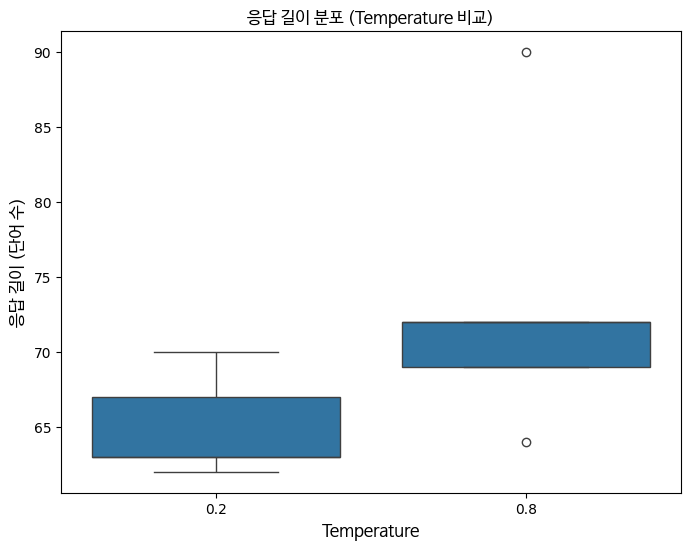

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import pandas as pd  # Import pandas

# 한글 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 나눔바른고딕 경로
fontprop = fm.FontProperties(fname=font_path, size=12)

# 데이터 준비
lengths_low = df_low["word_count"]  # temperature 0.2 응답 길이
lengths_high = df_high["word_count"] # temperature 0.8 응답 길이

# Create a DataFrame for seaborn
data = pd.DataFrame({
    "Temperature": ["0.2"] * len(lengths_low) + ["0.8"] * len(lengths_high),
    "Word Count": lengths_low.tolist() + lengths_high.tolist()
})

# seaborn을 사용하여 box plot 생성
plt.figure(figsize=(8, 6))  # 그림 크기 설정
sns.boxplot(x="Temperature", y="Word Count", data=data)  # Use the DataFrame

# 제목, 레이블 설정
plt.title("응답 길이 분포 (Temperature 비교)", fontproperties=fontprop)
plt.xlabel("Temperature", fontproperties=fontprop)
plt.ylabel("응답 길이 (단어 수)", fontproperties=fontprop)

# 그래프 출력
plt.show()

##실습7.9. 시각화 실습 : temperature 변화에 따른 핵심 키워드 포함 비율

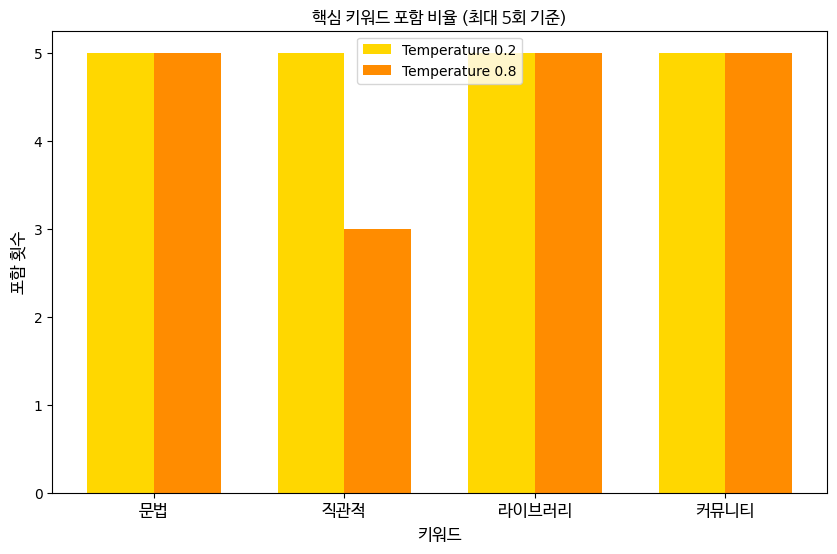

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import numpy as np

# 한글 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 나눔바른고딕 경로
fontprop = fm.FontProperties(fname=font_path, size=12)

# 키워드 포함 비율 계산
keywords = ["문법", "직관적", "라이브러리", "커뮤니티"]
rates_low = {kw: df_low[kw].sum() for kw in keywords}  # Temperature 0.2에서 키워드 등장 횟수
rates_high = {kw: df_high[kw].sum() for kw in keywords}  # Temperature 0.8에서 키워드 등장 횟수

# 막대 그래프 생성
bar_width = 0.35  # 막대 너비
index = np.arange(len(keywords))  # 키워드 위치

fig, ax = plt.subplots(figsize=(10, 6))  # Figure 및 Axes 객체 생성

# Temperature 0.2 막대 (노란색)
rects1 = ax.bar(index, rates_low.values(), bar_width, color='gold', label='Temperature 0.2')

# Temperature 0.8 막대 (주황색)
rects2 = ax.bar(index + bar_width, rates_high.values(), bar_width, color='darkorange', label='Temperature 0.8')

# 제목, 레이블, 범례 설정
ax.set_title('핵심 키워드 포함 비율 (최대 5회 기준)', fontproperties=fontprop)
ax.set_xlabel('키워드', fontproperties=fontprop)
ax.set_ylabel('포함 횟수', fontproperties=fontprop)
ax.set_xticks(index + bar_width / 2)  # x축 눈금 위치 조정
ax.set_xticklabels(keywords, fontproperties=fontprop)  # x축 눈금 레이블 설정
ax.legend()

plt.show()

##실습7.10. 파일 저장

In [ ]:
# 데이터프레임을 CSV 파일로 저장
df_high.to_csv('prompt_responses_high.csv', index=False, encoding='utf-8')
df_low.to_csv('prompt_responses_low.csv', index=False, encoding='utf-8')

# 데이터프레임을 JSON 파일로 저장 (records 형식)
df_high.to_json('prompt_responses_high.json', orient='records', force_ascii=False)
df_low.to_json('prompt_responses_low.json', orient='records', force_ascii=False)